In [ ]:
### Load mining report
# load mining report and uhvdb final ids
import polars as pl

# create a set of the final sequence ids from uhvdb
uhvdb_genomovars = set(
    pl.read_csv('uhvdb.vclust_genomovars_reps.tsv', has_header=False, new_columns=['seq_name'])
        ['seq_name']
)

# combine uhgv metadata
# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv
uhvdb_uhgv_meta = (
    pl.read_csv('uhgv_metadata.tsv', separator='\t', columns=['uhgv_genome', 'checkv_quality'])
        .filter(pl.col('uhgv_genome').is_in(uhvdb_genomovars))
        .rename({'uhgv_genome': 'seq_name'})
        .with_columns([
            pl.lit('UHGV').alias('source_db')
        ])
)

# filter mine report to only those in final uhvdb
mine_report_uhvdb = (
    pl.read_csv('viruses.csvtk_concat.tsv', separator='\t', columns=['seq_name', 'source_db', 'checkv_quality'])
        .filter(pl.col('seq_name').is_in(uhvdb_genomovars))
        .unique('seq_name')
)

mine_report_uhvdb_final = pl.concat([mine_report_uhvdb, uhvdb_uhgv_meta]).unique('seq_name')

pl.Config(tbl_rows=15)
mine_report_uhvdb_final.group_by('source_db').len().sort('len', descending=True)
# oral dbs: OPD, OVD,
# gut dbs: UHGV, CNGVC, CNGVR
# skin: SMGC
# urogential: VMGC
# mixed: IMGVR, CHVD, MMGE

source_db,len
str,u32
"""UHGV""",137464
"""SPIRE""",102307
"""OPD""",46656
"""CNGVC""",44994
"""CNGVR""",30353
"""ENA""",30152
"""IMGVR""",21458
"""MMGE""",17410
"""CHVD""",11287


In [ ]:
### annotate ENA sequences with body site
# ena_meta = pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/uhvdb/mine/ena/ena_metagenomes_2025_08_29.tsv', separator='\t')

# # create set of ena oral samples
# ena_oral_samples = set(
#     ena_meta
#         .filter(
#             (pl.col('scientific_name').str.contains('oral')) |
#             (pl.col('scientific_name').str.contains('nasopharyngeal')) |
#             (pl.col('scientific_name').str.contains('lung')) |
#             (pl.col('scientific_name').str.contains('saliva '))
#         )['analysis_accession']
# )

# ena_skin_samples = set(
#     ena_meta
#         .filter(
#             (pl.col('scientific_name').str.contains('skin'))
#         )['analysis_accession']
# )

# ena_urogenital_samples = set(
#     ena_meta
#         .filter(
#             (pl.col('scientific_name').str.contains('vaginal ')) |
#             (pl.col('scientific_name').str.contains('urinary'))
#         )['analysis_accession']
# )

In [ ]:
### annotate Loagn sequences with body site
# sra_meta = (
#     pl.read_parquet('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/uhvdb/mine/logan/2025_05_29_sra_metadata.parquet',
#         columns=['acc', 'organism']
#     )
# )

# # write out file of most prevalent organisms
# (
#     sra_meta
#         .group_by('organism')
#         .len()
#         .sort('len', descending=True)
#         .write_csv('sra_metagenomes_top_organisms.csv')
# )

# # identify human-associated metagenomes
# human_organisms = set([
#     'human oral metagenome',
#     'human nasopharyngeal metagenome',
#     'oral metagenome',
#     'human lung metagenome',
#     'respiratory tract metagenome',
#     'human saliva metagenome',
#     'upper respiratory tract metagenome',
#     'human sputum metagenome',
#     'lung metagenome',
#     'human tracheal metagenome',
#     'oral-nasopharyngeal metagenome',
#     'human skin metagenome',
#     'skin metagenome',
#     'human vaginal metagenome',
#     'vaginal metagenome',
#     'human urinary tract metagenome',
#     'urinary tract metagenome',
#     'human reproductive system metagenome',
#     'reproductive system metagenome'
# ])

# sra_meta_human = (
#     sra_meta
#         .filter(
#             (pl.col('organism').is_in(human_organisms))
#         )
# )

# # identify samples in logan
# # !wget https://s3.amazonaws.com/logan-pub/stats/logan-seqstats-contigs-v1.1.parquet
# logan_stats = pl.read_parquet('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/uhvdb/mine/logan/logan-seqstats-contigs-v1.1.parquet')
# sra_meta_human_logan = (
#     sra_meta_human
#         .filter(pl.col('acc').is_in(logan_stats['accession']))
# )

# # create set of logan oral samples
# logan_oral_samples = set(
#     sra_meta_human_logan
#         .filter(
#             (pl.col('organism').str.contains('human oral metagenome')) |
#             (pl.col('organism').str.contains('human nasopharyngeal metagenome')) |
#             (pl.col('organism').str.contains('oral metagenome')) |
#             (pl.col('organism').str.contains('respiratory tract metagenome')) |
#             (pl.col('organism').str.contains('human lung metagenome')) |
#             (pl.col('organism').str.contains('human saliva metagenome')) |
#             (pl.col('organism').str.contains('upper respiratory tract metagenome')) |
#             (pl.col('organism').str.contains('human sputum metagenome')) |
#             (pl.col('organism').str.contains('lung metagenome')) |
#             (pl.col('organism').str.contains('human tracheal metagenome')) |
#             (pl.col('organism').str.contains('oral-nasopharyngeal metagenome'))
#         )['acc']
# )

# logan_skin_samples = set(
#     sra_meta_human_logan
#         .filter(
#             (pl.col('organism').str.contains('human skin metagenome')) |
#             (pl.col('organism').str.contains('skin metagenome'))
#         )['acc']
# )

# logan_urogenital_samples = set(
#     sra_meta_human_logan
#         .filter(
#             (pl.col('organism').str.contains('human vaginal metagenome')) |
#             (pl.col('organism').str.contains('vaginal metagenome')) |
#             (pl.col('organism').str.contains('human urinary tract metagenome')) |
#             (pl.col('organism').str.contains('urinary tract metagenome')) |
#             (pl.col('organism').str.contains('human reproductive system metagenome')) |
#             (pl.col('organism').str.contains('reproductive system metagenome'))
#         )['acc']
# )


In [ ]:
### annotate SPIRE sequences with body site
# # load spire microontoloy
# spire_ont = (
#     pl.read_csv("https://swifter.embl.de/~fullam/spire/metadata/spire_v1_microntology.tsv.gz", separator="\t", has_header=False)
#     .with_columns(
#         pl.col("column_1").str.splitn(by=" ", n=3)
#         .struct.rename_fields(["biosample", "bioproject", "ontology"])
#         .alias("fields")
#     ).unnest("fields")
# )

# # identify most common ontologies
# (
#     spire_ont
#         .filter(pl.col("ontology").str.contains("animal host"))
#         .group_by("ontology")
#         .len()
#         .sort('len', descending=True)
#         .write_csv("spire_animal_host_ontologies.csv")
# )

# # filter to human airways, skin, and urogenital samples
# spire_human = (
#     spire_ont
#         .filter(
#             (pl.col("ontology").str.contains("animal host")) &
#             (
#                 (pl.col("ontology").str.contains("mouth")) |
#                 (pl.col("ontology").str.contains("airway")) |
#                 (pl.col("ontology").str.contains("urogenital")) |
#                 (pl.col("ontology").str.contains("skin"))
#             )
#         )
#         .unique('biosample')
# )

# # create set of spire oral samples
# spire_oral_samples = set(
#     spire_human
#         .filter(
#             (pl.col("ontology").str.contains("animal host")) &
#             (
#                 (pl.col("ontology").str.contains("mouth")) |
#                 (pl.col("ontology").str.contains("airway"))
#             )
#         )['biosample']
# )

# # create set of ena skin samples
# spire_skin_samples = set(
#     spire_human
#         .filter(
#             (pl.col("ontology").str.contains("animal host")) &
#             (
#                 (pl.col("ontology").str.contains("skin"))
#             )
#         )['biosample']
# )

# # create set of ena urogenital samples
# spire_urogenital_samples = set(
#     spire_human
#         .filter(
#             (pl.col("ontology").str.contains("animal host")) &
#             (
#                 (pl.col("ontology").str.contains("urogenital"))
#             )
#         )['biosample']
# )

In [ ]:
### annotate IMGVR sequences with body site
# imgvr_meta = pl.read_csv('IMGVR_all_Sequence_information.tsv',
#     separator='\t', columns=['UVIG', 'Ecosystem classification'])

# # identify human samples
# (
#     imgvr_meta
#         .filter(
#             (pl.col('Ecosystem classification').str.contains('Human'))
#         )
#         .group_by('Ecosystem classification')
#         .len()
#         .sort(pl.col('len'), descending=True)
#         .write_csv('IMGVR_human_ecosystem_classification_counts.csv')
# )

# imgvr_human_uvigs = (
#     imgvr_meta
#         .filter(
#             (pl.col('Ecosystem classification').str.contains('Human'))
#         )
# )

# # create set of imgvr gut samples
# imgvr_gut_samples = set(
#     imgvr_human_uvigs
#         .filter(
#             (
#                 (pl.col("Ecosystem classification").str.contains("intestine"))
#             )
#         )['UVIG']
# )

# # create set of imgvr oral samples
# imgvr_oral_samples = set(
#     imgvr_human_uvigs
#         .filter(
#             (
#                 (pl.col("Ecosystem classification").str.contains("Oral")) |
#                 (pl.col("Ecosystem classification").str.contains("Pharynx")) |
#                 (pl.col("Ecosystem classification").str.contains("Sputum")) |
#                 (pl.col("Ecosystem classification").str.contains("Tonsils")) |
#                 (pl.col("Ecosystem classification").str.contains("Nasal")) |
#                 (pl.col("Ecosystem classification").str.contains("Trachea")) |
#                 (pl.col("Ecosystem classification").str.contains("Lung")) |
#                 (pl.col("Ecosystem classification").str.contains("Throat"))
#             )
#         )['UVIG']
# )

# # create set of imgvr skin samples
# imgvr_skin_samples = set(
#     imgvr_human_uvigs
#         .filter(
#             (
#                 (pl.col("Ecosystem classification").str.contains("Skin"))
#             )
#         )['UVIG']
# )

# # create set of spire urogenital samples
# imgvr_urogenital_samples = set(
#     imgvr_human_uvigs
#         .filter(
#             (
#                 (pl.col("Ecosystem classification").str.contains("Vagina")) |
#                 (pl.col("Ecosystem classification").str.contains("Urine")) |
#                 (pl.col("Ecosystem classification").str.contains("Urethra")) |
#                 (pl.col("Ecosystem classification").str.contains("Uterus")) |
#                 (pl.col("Ecosystem classification").str.contains("Urinary"))
#             )
#         )['UVIG']
# )

In [ ]:
### annotate MMGE sequences with body site
# # !wget wget https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
# # !unzip all_mge_inf.zip
# mmge_meta = (
#     pl.read_csv('all_mge_inf.csv')
#         .with_columns([
#             pl.col('sam_ids').str.split(',')
#         ])
# )

# # !wget https://mai.fudan.edu.cn/mgedb/client/file/all_sample_inf.zip
# # !unzip all_sample_inf.zip
# mmge_sample_meta = pl.read_csv('sampleInfo.csv')

# mmge_gut_samples = set(
#     mmge_sample_meta
#         .filter(
#             (pl.col('BodySite').str.contains('Gut'))
#         )['NCBI_Run_ID']
# )

# mmge_oral_samples = set(
#     mmge_sample_meta
#         .filter(
#             (pl.col('BodySite').str.contains('Oral')) |
#             (pl.col('BodySite').str.contains('Nasopharyngeal')) |
#             (pl.col('BodySite').str.contains('Sputum')) |
#             (pl.col('BodySite').str.contains('Tooth')) |
#             (pl.col('BodySite').str.contains('Trachea')) |
#             (pl.col('BodySite').str.contains('Lung'))
#         )['NCBI_Run_ID']
# )

# mmge_skin_samples = set(
#     mmge_sample_meta
#         .filter(
#             (pl.col('BodySite').str.contains('Skin'))
#         )['NCBI_Run_ID']
# )

# mmge_urogenital_samples = set(
#     mmge_sample_meta
#         .filter(
#             (pl.col('BodySite').str.contains('Vagina')) |
#             (pl.col('BodySite').str.contains('Urethra')) |
#             (pl.col('BodySite').str.contains('Reproductive system'))
#         )['NCBI_Run_ID']
# )

# mmge_gut_seqs = set(
#     mmge_meta
#         .filter(
#             pl.col("sam_ids").list.eval(
#                 pl.element().is_in(mmge_gut_samples)
#             ).list.any()
#         )['MGEs_id']
# )

# mmge_oral_seqs = set(
#     mmge_meta
#         .filter(
#             pl.col("sam_ids").list.eval(
#                 pl.element().is_in(mmge_oral_samples)
#             ).list.any()
#         )['MGEs_id']
# )

# mmge_skin_seqs = set(
#     mmge_meta
#         .filter(
#             pl.col("sam_ids").list.eval(
#                 pl.element().is_in(mmge_skin_samples)
#             ).list.any()
#         )['MGEs_id']
# )

# mmge_urogenital_seqs = set(
#     mmge_meta
#         .filter(
#             pl.col("sam_ids").list.eval(
#                 pl.element().is_in(mmge_urogenital_samples)
#             ).list.any()
#         )['MGEs_id']
# )

In [ ]:
### Count the number of virus sequences from each body site
# num_gut_seqs = (
#     93462 + # CNGVC
#     120568 + # CNGVR
#     212415 + # UHGV
#     len(imgvr_gut_samples) +
#     len(mmge_gut_seqs)
# )

# num_oral_seqs = (
#     189859 + # OPD
#     48425 + # OVD
#     len(imgvr_oral_samples) +
#     len(mmge_oral_seqs)
# )

# num_skin_seqs = (
#     6935 + # SMGC
#     len(imgvr_skin_samples) +
#     len(mmge_skin_seqs)
# )

# num_urogenital_seqs = (
#     14224 + # VMGC
#     len(imgvr_urogenital_samples) +
#     len(mmge_urogenital_seqs)
# )

# print(f'Number of gut sequences: {num_gut_seqs}')
# print(f'Number of oral sequences: {num_oral_seqs}')
# print(f'Number of skin sequences: {num_skin_seqs}')
# print(f'Number of urogenital sequences: {num_urogenital_seqs}')

Number of gut sequences: 1207742
Number of oral sequences: 425693
Number of skin sequences: 42417
Number of urogenital sequences: 17960


In [ ]:
### count the number of assemblies from each body site
# num_oral_samps = (
#     len(ena_oral_samples) +
#     len(logan_oral_samples) +
#     len(spire_oral_samples)
# )

# num_skin_samps = (
#     len(ena_skin_samples) +
#     len(logan_skin_samples) +
#     len(spire_skin_samples)
# )

# num_urogenital_samps = (
#     len(ena_urogenital_samples) +
#     len(logan_urogenital_samples) +
#     len(spire_urogenital_samples)
# )

# print('Number of gut samples: 0')
# print(f'Number of oral samples: {num_oral_samps}')
# print(f'Number of skin samples: {num_skin_samps}')
# print(f'Number of urogenital samples: {num_urogenital_samps}')

Number of gut samples: 0
Number of oral samples: 47194
Number of skin samples: 23763
Number of urogenital samples: 8174


In [ ]:
### assign each UHVDB virus to a body site 
# uhvdb_plot_df = (
#     mine_report_uhvdb_final
#         .with_columns([
#             pl.when(pl.col('source_db') == 'OPD').then(pl.lit('Oral'))
#                 .when(pl.col('source_db') == 'OVD').then(pl.lit('Oral'))
#                 .when(pl.col('source_db') == 'CNGVC').then(pl.lit('Gut'))
#                 .when(pl.col('source_db') == 'CNGVR').then(pl.lit('Gut'))
#                 .when(pl.col('source_db') == 'UHGV').then(pl.lit('Gut'))
#                 .when(pl.col('source_db') == 'SMGC').then(pl.lit('Skin'))
#                 .when(pl.col('source_db') == 'VMGC').then(pl.lit('Urogenital'))
#                 .when(
#                     (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_gut_samples))
#                 ).then(pl.lit('Gut'))
#                 .when(
#                     (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_oral_samples))
#                 ).then(pl.lit('Oral'))
#                 .when(
#                     (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_skin_samples))
#                 ).then(pl.lit('Skin'))
#                 .when(
#                     (pl.col('source_db') == 'IMGVR') & (pl.col('seq_name').str.split('|').list[0].is_in(imgvr_urogenital_samples))
#                 ).then(pl.lit('Urogenital'))
#                 .when(
#                     (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_gut_seqs))
#                 ).then(pl.lit('Gut'))
#                 .when(
#                     (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_oral_seqs))
#                 ).then(pl.lit('Oral'))
#                 .when(
#                     (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_skin_seqs))
#                 ).then(pl.lit('Skin'))
#                 .when(
#                     (pl.col('source_db') == 'MMGE') & (pl.col('seq_name').str.split('|').list[0].is_in(mmge_urogenital_seqs))
#                 ).then(pl.lit('Urogenital'))
#                 .when(
#                     (pl.col('source_db') == 'ENA') & (pl.col('seq_name').str.split('.').list[0].is_in(ena_oral_samples))
#                 ).then(pl.lit('Oral'))
#                 .when(
#                     (pl.col('source_db') == 'ENA') & (pl.col('seq_name').str.split('.').list[0].is_in(ena_skin_samples))
#                 ).then(pl.lit('Skin'))
#                 .when(
#                     (pl.col('source_db') == 'ENA') & (pl.col('seq_name').str.split('.').list[0].is_in(ena_urogenital_samples))
#                 ).then(pl.lit('Urogenital'))
#                 .when(
#                     (pl.col('source_db') == 'LOGAN') & (pl.col('seq_name').str.split('_').list[0].is_in(logan_oral_samples))
#                 ).then(pl.lit('Oral'))
#                 .when(
#                     (pl.col('source_db') == 'LOGAN') & (pl.col('seq_name').str.split('_').list[0].is_in(logan_skin_samples))
#                 ).then(pl.lit('Skin'))
#                 .when(
#                     (pl.col('source_db') == 'LOGAN') & (pl.col('seq_name').str.split('_').list[0].is_in(logan_urogenital_samples))
#                 ).then(pl.lit('Urogenital'))
#                 .when(
#                     (pl.col('source_db') == 'SPIRE') & (pl.col('seq_name').str.split('_').list[0].is_in(spire_oral_samples))
#                 ).then(pl.lit('Oral'))
#                 .when(
#                     (pl.col('source_db') == 'SPIRE') & (pl.col('seq_name').str.split('_').list[0].is_in(spire_skin_samples))
#                 ).then(pl.lit('Skin'))
#                 .when(
#                     (pl.col('source_db') == 'SPIRE') & (pl.col('seq_name').str.split('_').list[0].is_in(spire_urogenital_samples))
#                 ).then(pl.lit('Urogenital'))
#                 .otherwise(pl.lit('Other/Unknown'))
#                 .alias('body_site')
#         ])
# )

In [ ]:
### write out metadata so above code does not need to be rerun
# (
#     uhvdb_plot_df
#         .with_columns([
#                 pl.when(pl.col('source_db').is_in(['CNGVC', 'CNGVR', 'UHGV', 'MMGE', 'OPD', 'OVD', 'IMGVR', 'CHVD', 'SMGC', 'VMGC']))
#                     .then(pl.lit('Database'))
#                     .otherwise(pl.lit('Assembly'))
#                     .alias('db_type')
#             ])
# ).write_csv('uhvdb_final_metadata.tsv', separator='\t')

In [ ]:
### Load metadata
import polars as pl
# load UHVDB metadata
uhvdb_plot_df = pl.read_csv('uhvdb_final_metadata.tsv', separator='\t')

# count number of sequences with unknown body site by source db
uhvdb_plot_df.filter((pl.col('body_site') == 'Other/Unknown')).group_by('source_db').len().sort('len', descending=True)

source_db,len
str,u32
"""MMGE""",14490
"""CHVD""",11161
"""IMGVR""",5381
"""SPIRE""",187


In [3]:
# count number of sequences by body site
uhvdb_plot_df.group_by('body_site').len().sort('len', descending=True)

body_site,len
str,u32
"""Gut""",220497
"""Oral""",182638
"""Other/Unknown""",31219
"""Skin""",5864
"""Urogenital""",5372


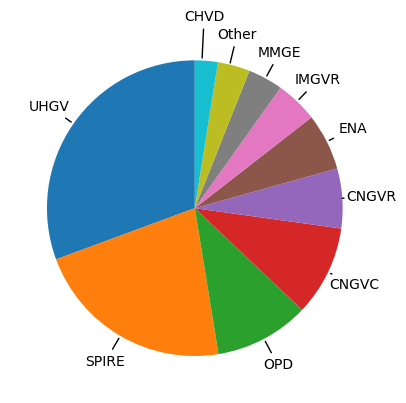

In [8]:
### figure 1c pie chart of source dbs
import matplotlib.pyplot as plt
import numpy as np

source_db_plot = (
    uhvdb_plot_df
        .with_columns([pl.when(pl.col('source_db').is_in(['OVD', 'SMGC', 'VMGC', 'LOGAN'])).then(pl.lit('Other')).otherwise(pl.col('source_db')).alias('source_db')])
        .group_by('source_db')
        .len()
        .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots()

# Make pie without labels
wedges, texts = ax.pie(source_db_plot['len'], startangle=90)

for i, wedge in enumerate(wedges):
    theta = (wedge.theta2 + wedge.theta1) / 2.0  # mid angle in degrees
    x = np.cos(np.deg2rad(theta))
    y = np.sin(np.deg2rad(theta))

    x_text = 1.2
    y_text = 1.2

    if source_db_plot['source_db'][i] == 'CHVD':
        x = x - 0.03
        # y = y + 0.05
        x_text = 1.3
        y_text = 1.3
    if source_db_plot['source_db'][i] == 'Other':
        x = x - 0.03
        # y = y + 0.05
        x_text = 1.22
        y_text = 1.22

    # Place label at 1.2x radius
    ax.annotate(
        f"{source_db_plot['source_db'][i]}",    # label text
        xy=(x, y),                              # point on slice edge
        xytext=(x_text * x, y_text * y),        # label position (further out)
        ha="center", va="center",
        arrowprops=dict(arrowstyle="-")         # draw line
    )

plt.show()

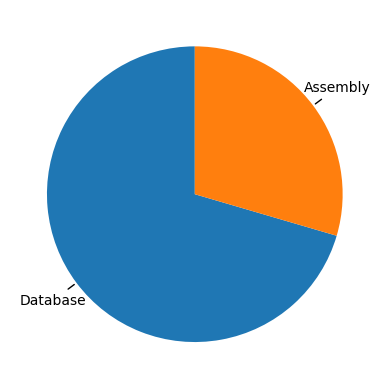

In [ ]:
### Figure 1c pie chart of database vs assembly source
import matplotlib.pyplot as plt

source_type_plot = (
    uhvdb_plot_df
        .with_columns([
            pl.when(pl.col('source_db').is_in(['CNGVC', 'CNGVR', 'UHGV', 'MMGE', 'OPD', 'OVD', 'IMGVR', 'CHVD', 'SMGC', 'VMGC']))
                .then(pl.lit('Database'))
                .otherwise(pl.lit('Assembly'))
                .alias('db_type')
        ])
        .group_by('db_type')
        .len()
        .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots()

# Make pie without labels
wedges, texts = ax.pie(source_type_plot['len'], startangle=90)

for i, wedge in enumerate(wedges):
    theta = (wedge.theta2 + wedge.theta1) / 2.0  # mid angle in degrees
    x = np.cos(np.deg2rad(theta))
    y = np.sin(np.deg2rad(theta))

    x_text = 1.2
    y_text = 1.2

    # Place label at 1.2x radius
    ax.annotate(
        f"{source_type_plot['db_type'][i]}",    # label text
        xy=(x, y),                              # point on slice edge
        xytext=(x_text * x, y_text * y),        # label position (further out)
        ha="center", va="center",
        arrowprops=dict(arrowstyle="-")         # draw line
    )

plt.show()

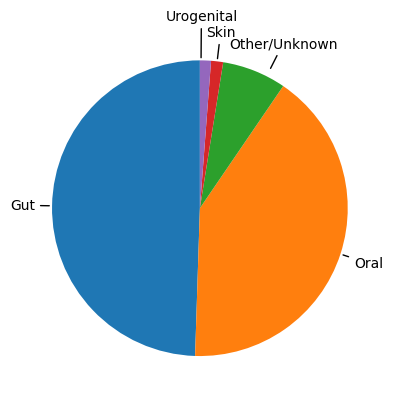

In [ ]:
### figure 1c pie chart of body site
import matplotlib.pyplot as plt

body_site_plot = (
    uhvdb_plot_df
        .group_by('body_site')
        .len()
        .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots()

# Make pie without labels
wedges, texts = ax.pie(body_site_plot['len'], startangle=90)

for i, wedge in enumerate(wedges):
    theta = (wedge.theta2 + wedge.theta1) / 2.0  # mid angle in degrees
    x = np.cos(np.deg2rad(theta))
    y = np.sin(np.deg2rad(theta))

    x_text = 1.2
    y_text = 1.2

    if body_site_plot['body_site'][i] == 'Urogenital':
        x = x - 0.03
        # y = y + 0.05
        x_text = 1.3
        y_text = 1.3

    if body_site_plot['body_site'][i] == 'Other/Unknown':
        x = x + 0.1
        # y = y + 0.05
        x_text = 1.2
        y_text = 1.2

    # Place label at 1.2x radius
    ax.annotate(
        f"{body_site_plot['body_site'][i]}",    # label text
        xy=(x, y),                              # point on slice edge
        xytext=(x_text * x, y_text * y),        # label position (further out)
        ha="center", va="center",
        arrowprops=dict(arrowstyle="-")         # draw line
    )

plt.show()

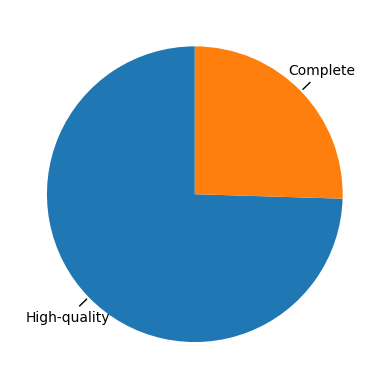

In [ ]:
### figure 1c pie chart of CheckV quality
import matplotlib.pyplot as plt

checkv_quality_plot = (
    uhvdb_plot_df
        .group_by('checkv_quality')
        .len()
        .sort('len', descending=True)
)

plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots()

# Make pie without labels
wedges, texts = ax.pie(checkv_quality_plot['len'], startangle=90)

for i, wedge in enumerate(wedges):
    theta = (wedge.theta2 + wedge.theta1) / 2.0  # mid angle in degrees
    x = np.cos(np.deg2rad(theta))
    y = np.sin(np.deg2rad(theta))

    x_text = 1.2
    y_text = 1.2

    # Place label at 1.2x radius
    ax.annotate(
        f"{checkv_quality_plot['checkv_quality'][i]}",    # label text
        xy=(x, y),                              # point on slice edge
        xytext=(x_text * x, y_text * y),        # label position (further out)
        ha="center", va="center",
        arrowprops=dict(arrowstyle="-")         # draw line
    )

plt.show()